### 1. Import libraries and environment setup

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_curve, auc
from xgboost import XGBClassifier
import os

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


### 2. Load test dataset and saved models

In [ ]:
print("Loading test dataset...")
X_test, y_test = joblib.load('../data/processed/test_data.joblib')
print(f"Test dataset shape: X={X_test.shape}, y={y_test.shape}")

print("\nLoading AI models...")
rf_model = joblib.load('../models/random_forest_v1.joblib')
print("- Random Forest model loaded successfully.")

xgb_model = XGBClassifier()
xgb_model.load_model('../models/xgboost_v1.json')
print("- XGBoost model loaded successfully.")

Loading test dataset...
Test dataset shape: X=(424182, 40), y=(424182,)

Loading AI models...
- Random Forest model loaded successfully.
- XGBoost model loaded successfully.


### 3. Model Evaluation on Test Data

In [ ]:
print("Generating predictions for Random Forest...")
rf_preds = rf_model.predict(X_test)

print("Generating predictions for XGBoost...")
xgb_preds = xgb_model.predict(X_test)

print("\n--- Random Forest Classification Report (Test Set) ---")
print(classification_report(y_test, rf_preds, digits=4))

print("\n--- XGBoost Classification Report (Test Set) ---")
print(classification_report(y_test, xgb_preds, digits=4))

Generating predictions for Random Forest...
Generating predictions for XGBoost...

--- Random Forest Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0     0.9999    0.9989    0.9994    340698
           1     0.9955    0.9995    0.9975     83484

    accuracy                         0.9990    424182
   macro avg     0.9977    0.9992    0.9984    424182
weighted avg     0.9990    0.9990    0.9990    424182


--- XGBoost Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0     0.9999    0.9991    0.9995    340698
           1     0.9963    0.9997    0.9980     83484

    accuracy                         0.9992    424182
   macro avg     0.9981    0.9994    0.9988    424182
weighted avg     0.9992    0.9992    0.9992    424182



### 4. Confusion Matrix and NIDS-Specific Metrics
In cybersecurity, general accuracy is not sufficient due to high class imbalance. We must closely monitor two critical metrics:
* **FPR (False Positive Rate):** Harmless background traffic incorrectly classified as an attack (causes alert fatigue).
* **FNR (False Negative Rate):** Actual attacks missed by the system (critical security risk).

Calculating NIDS-specific metrics...

--- Random Forest NIDS Metrics ---
False Positive Rate (FPR): 0.001112 (379 false alarms)
False Negative Rate (FNR): 0.000527 (44 missed attacks)

--- XGBoost NIDS Metrics ---
False Positive Rate (FPR): 0.000898 (306 false alarms)
False Negative Rate (FNR): 0.000311 (26 missed attacks)



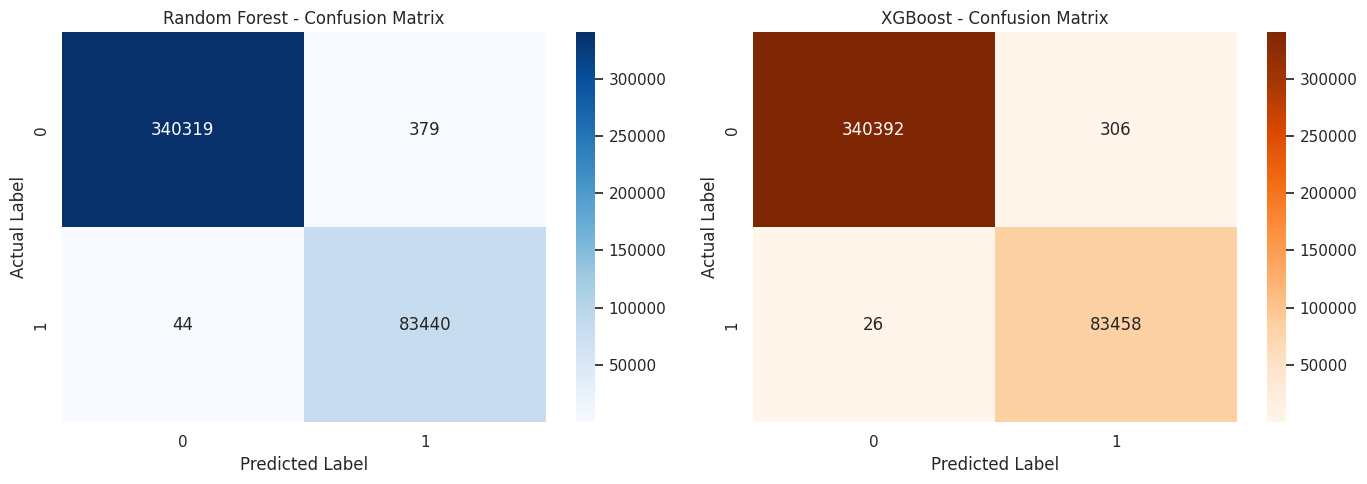

In [ ]:
def evaluate_nids_metrics(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    
    print(f"--- {model_name} NIDS Metrics ---")
    print(f"False Positive Rate (FPR): {fpr:.6f} ({fp} false alarms)")
    print(f"False Negative Rate (FNR): {fnr:.6f} ({fn} missed attacks)\n")
    
    return cm

print("Calculating NIDS-specific metrics...\n")
rf_cm = evaluate_nids_metrics(y_test, rf_preds, "Random Forest")
xgb_cm = evaluate_nids_metrics(y_test, xgb_preds, "XGBoost")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest - Confusion Matrix')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('XGBoost - Confusion Matrix')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### 5. Precision-Recall Curve and Threshold Tuning (XGBoost)

Extracting prediction probabilities for XGBoost...


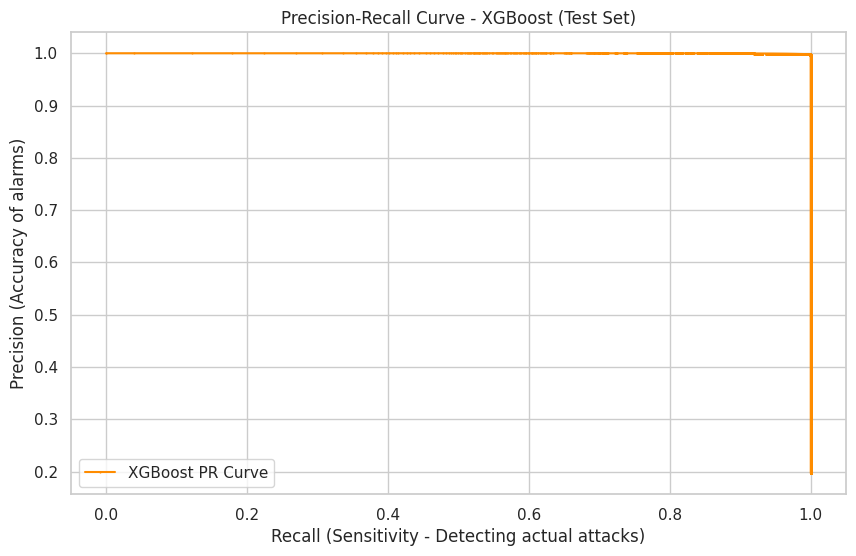


--- Threshold Optimization ---
To achieve at least 99.9% Precision:
Suggested Decision Threshold: 0.9942
Corresponding Recall we can expect: 0.9732


In [ ]:
print("Extracting prediction probabilities for XGBoost...")
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, xgb_probs)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.', markersize=1, label='XGBoost PR Curve', color='darkorange')
plt.title('Precision-Recall Curve - XGBoost (Test Set)')
plt.xlabel('Recall (Sensitivity - Detecting actual attacks)')
plt.ylabel('Precision (Accuracy of alarms)')
plt.legend()
plt.show()

target_precision = 0.9990

idx = (precision >= target_precision).argmax()

optimal_threshold = thresholds[idx]
corresponding_recall = recall[idx]

print(f"\n--- Threshold Optimization ---")
print(f"To achieve at least {target_precision*100}% Precision:")
print(f"Suggested Decision Threshold: {optimal_threshold:.4f}")
print(f"Corresponding Recall we can expect: {corresponding_recall:.4f}")

### 6. Feature Importance Analysis

Calculating feature importances...


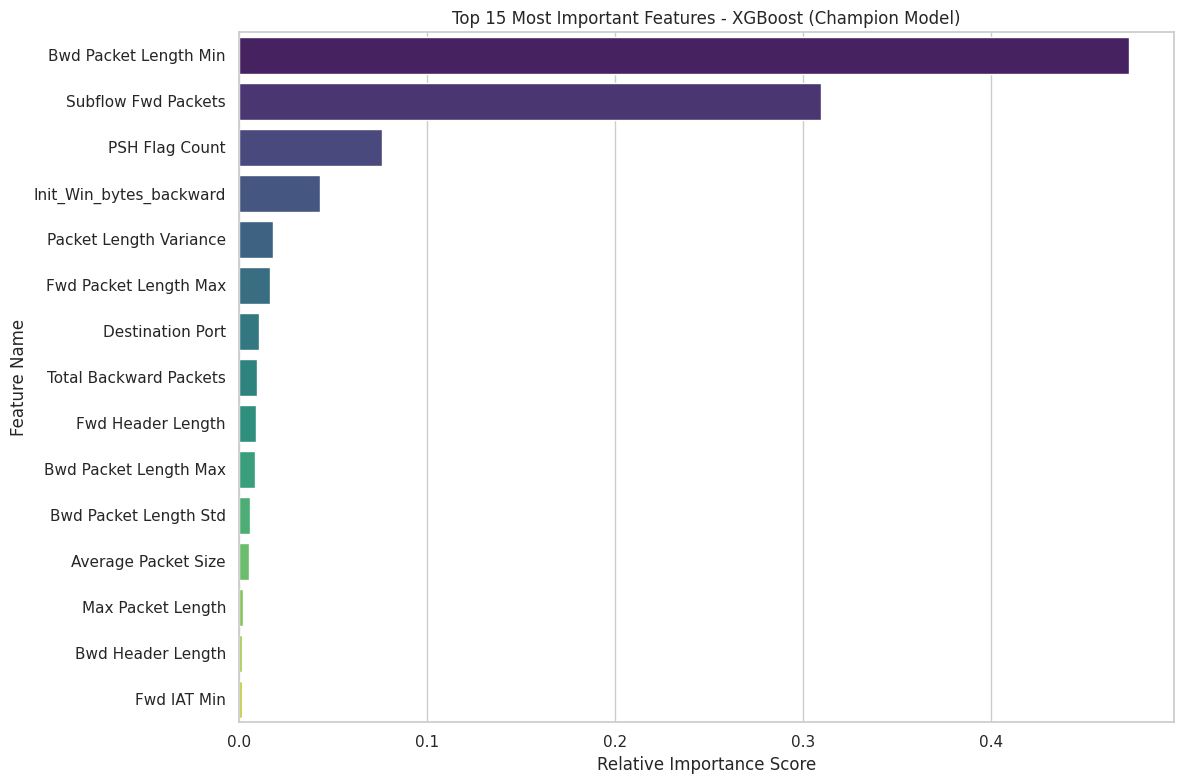


Top 5 features driving the model's decisions:
- Bwd Packet Length Min: 0.4739
- Subflow Fwd Packets: 0.3097
- PSH Flag Count: 0.0760
- Init_Win_bytes_backward: 0.0431
- Packet Length Variance: 0.0179


In [ ]:
print("Calculating feature importances...")

importances = xgb_model.feature_importances_
feature_names = X_test.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), hue='Feature', palette='viridis', legend=False)

plt.title('Top 15 Most Important Features - XGBoost (Champion Model)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

print("\nTop 5 features driving the model's decisions:")
for index, row in importance_df.head(5).iterrows():
    print(f"- {row['Feature']}: {row['Importance']:.4f}")